# Import

In [12]:
import os
import gzip
import pandas as pd
from datasets import load_dataset
from collections import Counter
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [13]:
def _read_conll_iob2_from_url(url: str, language: str, source_split: str):
    import requests
    r = requests.get(url, timeout=60)
    r.raise_for_status()

    rows = []
    sent_id = 0
    for line in r.text.splitlines():
        line = line.strip()
        if line == "":
            sent_id += 1
            continue
        parts = line.split()
        if len(parts) < 2:
            continue
        token, tag = parts[0], parts[-1]
        rows.append({
            "token": token,
            "tag": tag,
            "language": language,
            "source_split": source_split,   # ✅ сохраняем источник
            "sentence_id": f"{language}_{source_split}_{sent_id}"
        })
    return pd.DataFrame(rows)


def load_kaznerd():
    base = "https://raw.githubusercontent.com/IS2AI/KazNERD/main/KazNERD/"
    files = {"train": "IOB2_train.txt", "validation": "IOB2_valid.txt", "test": "IOB2_test.txt"}
    dfs = []
    for split, fname in files.items():
        dfs.append(_read_conll_iob2_from_url(base + fname, language="kaz", source_split=split))
    return pd.concat(dfs, ignore_index=True)

def load_nerus(path_conllu, max_sentences=20000):
    rows = []
    sent_id = 0
    with open(path_conllu, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if line == "" or line.startswith("#"):
                if line == "":
                    sent_id += 1
                    if sent_id >= max_sentences:
                        break
                continue

            parts = line.split("\t")
            if len(parts) < 2:
                continue

            token = parts[1]
            misc = parts[-1] if len(parts) >= 10 else ""

            tag = "O"
            if "Tag=" in misc:
                for piece in misc.split("|"):
                    if piece.startswith("Tag="):
                        tag = piece.split("=", 1)[1]
                        break

            rows.append({
                "token": token,
                "tag": tag,
                "language": "ru",
                "source_split": "train",
                "sentence_id": f"ru_{sent_id}"          # ✅ UNIQUE
            })
    return pd.DataFrame(rows)

def load_conll2003():
    ds = load_dataset("conll2003")
    ner_names = ds["train"].features["ner_tags"].feature.names

    rows = []
    for split in ["train", "validation", "test"]:
        for i, (tokens, tag_ids) in enumerate(zip(ds[split]["tokens"], ds[split]["ner_tags"])):
            sid = f"en_{split}_{i}"                           # ✅ UNIQUE
            for tok, tid in zip(tokens, tag_ids):
                rows.append({
                    "token": tok,
                    "tag": ner_names[tid],
                    "language": "en",
                    "source_split": split,
                    "sentence_id": sid
                })
    return pd.DataFrame(rows)

def sentence_level_rebalance(
    df,
    entity_ratio=0.7,
    random_state=42
):
    np.random.seed(random_state)

    balanced_parts = []

    for lang, lang_df in df.groupby("language"):
        sent_groups = lang_df.groupby("sentence_id")

        sent_has_entity = sent_groups["tag"].apply(lambda x: (x != "O").any())

        entity_sents = sent_has_entity[sent_has_entity].index
        o_sents = sent_has_entity[~sent_has_entity].index

        n_total = min(len(entity_sents) / entity_ratio, len(o_sents) / (1 - entity_ratio))
        n_total = int(n_total)

        n_entity = int(n_total * entity_ratio)
        n_o = n_total - n_entity

        sampled_entity = np.random.choice(entity_sents, size=n_entity, replace=False)
        sampled_o = np.random.choice(o_sents, size=n_o, replace=False)

        selected_ids = list(sampled_entity) + list(sampled_o)

        balanced_parts.append(lang_df[lang_df["sentence_id"].isin(selected_ids)])

        print(
            f"[{lang}] kept sentences: {len(selected_ids)} "
            f"(entity={n_entity}, O-only={n_o})"
        )

    return pd.concat(balanced_parts, ignore_index=True)

def split_per_language_overwrite(df, test_size=0.1, val_size=0.1, random_state=42):
    parts = []
    for lang, lang_df in df.groupby("language"):
        sent_ids = lang_df["sentence_id"].unique()

        train_ids, temp_ids = train_test_split(
            sent_ids,
            test_size=(test_size + val_size),
            random_state=random_state
        )
        rel_test = test_size / (test_size + val_size)
        val_ids, test_ids = train_test_split(
            temp_ids,
            test_size=rel_test,
            random_state=random_state
        )

        lang_df = lang_df.copy()
        lang_df["split"] = "train"
        lang_df.loc[lang_df["sentence_id"].isin(val_ids), "split"] = "validation"
        lang_df.loc[lang_df["sentence_id"].isin(test_ids), "split"] = "test"

        parts.append(lang_df)

    return pd.concat(parts, ignore_index=True)

In [14]:
kaz_df = load_kaznerd()
conll_df = load_conll2003()

nerus_path = "nerus_lenta.conllu"
ru_df = load_nerus(nerus_path, max_sentences=20000)

combined = pd.concat([kaz_df, ru_df, conll_df], ignore_index=True)

balanced = sentence_level_rebalance(
    combined,
    entity_ratio=0.7
)

out_cols = ["token", "tag", "language", "sentence_id", "source_split"]
balanced[out_cols].to_csv("multilingual_final.csv", index=False, encoding="utf-8")

print("\nFinal dataset saved: multilingual_final.csv")
print("Shape:", balanced[out_cols].shape)

[en] kept sentences: 14169 (entity=9918, O-only=4251)
[kaz] kept sentences: 108161 (entity=75712, O-only=32449)
[ru] kept sentences: 17345 (entity=12141, O-only=5204)

Final dataset saved: multilingual_final.csv
Shape: (1781096, 5)


In [15]:
df = pd.read_csv("multilingual_final.csv")

In [16]:
df = split_per_language_overwrite(df)

In [17]:
print(df[df["language"]=="ru"]["split"].value_counts())
print(df.groupby(["split","language"])["sentence_id"].nunique().unstack(fill_value=0))

split
train         259146
test           32742
validation     32295
Name: count, dtype: int64
language       en    kaz     ru
split                          
test         1417  10817   1735
train       11335  86528  13876
validation   1417  10816   1734


In [18]:
df = pd.read_csv("multilingual_final.csv")
df

,token,tag,language,sentence_id,source_split
0,EU,B-ORG,en,en_train_0,train
1,rejects,O,en,en_train_0,train
2,German,B-MISC,en,en_train_0,train
3,call,O,en,en_train_0,train
4,to,O,en,en_train_0,train
...,...,...,...,...,...
1781091,поделилось,O,ru,ru_19999,train
1781092,издание,O,ru,ru_19999,train
1781093,Daily,B-ORG,ru,ru_19999,train
1781094,Mail,I-ORG,ru,ru_19999,train


In [19]:
print("Total number of tokens:", len(df))
print("Number of offers:", df["sentence_id"].nunique())
print("\nLanguages in the dataset:", df["language"].unique())

Total number of tokens: 1781096
Number of offers: 139675

Languages in the dataset: ['en' 'kaz' 'ru']


In [20]:
tokens_per_lang = df.groupby("language").size()
print(tokens_per_lang)

language
en      199826
kaz    1257087
ru      324183
dtype: int64


In [21]:
sentences_per_lang = df.groupby("language")["sentence_id"].nunique()
print(sentences_per_lang)

language
en      14169
kaz    108161
ru      17345
Name: sentence_id, dtype: int64


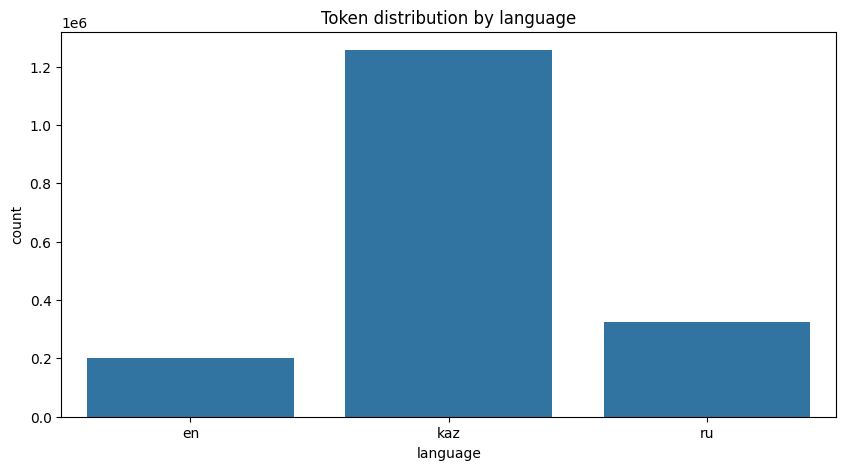

In [22]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="language")
plt.title("Token distribution by language")
plt.show()

In [23]:
tag_dist = (
    df.groupby(["language", "tag"])
      .size()
      .reset_index(name="count")
      .sort_values(["language", "count"], ascending=[True, False])
)

tag_dist.head(20)

,language,tag,count
8,en,O,169533
0,en,B-LOC,6419
3,en,B-PER,6052
2,en,B-ORG,5502
7,en,I-PER,4194
6,en,I-ORG,3054
1,en,B-MISC,3033
5,en,I-MISC,1041
4,en,I-LOC,998
59,kaz,O,991319


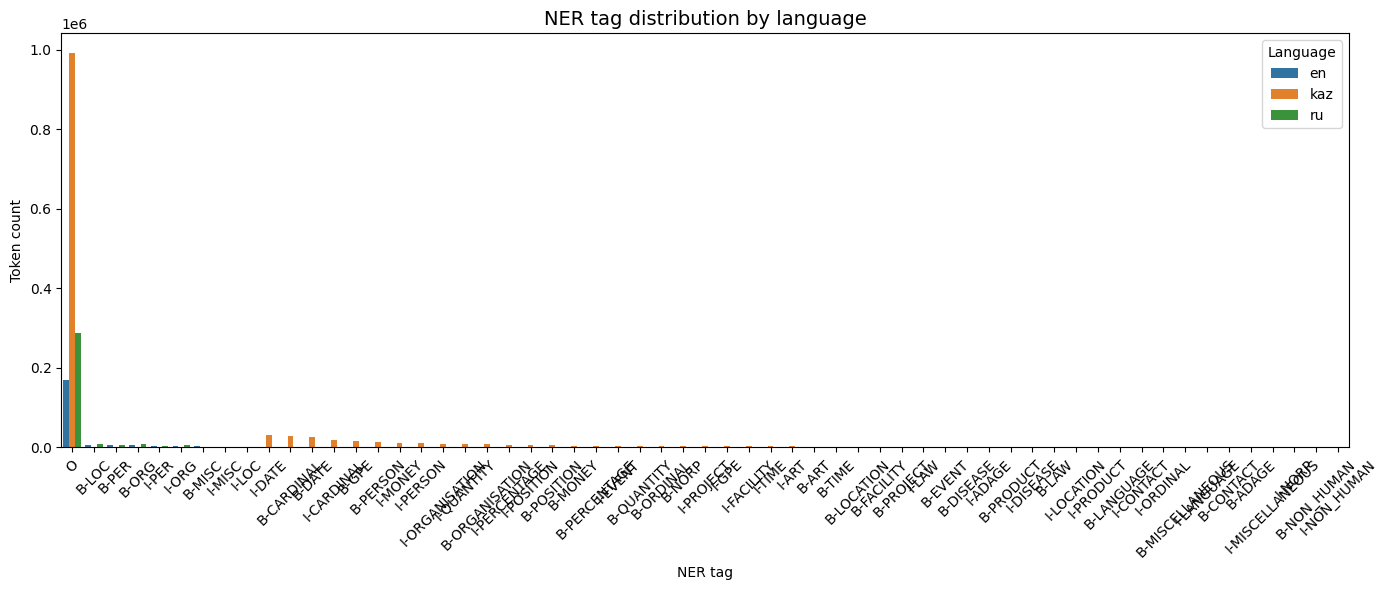

In [24]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=tag_dist,
    x="tag",
    y="count",
    hue="language"
)

plt.title("NER tag distribution by language", fontsize=14)
plt.xlabel("NER tag")
plt.ylabel("Token count")
plt.xticks(rotation=45)
plt.legend(title="Language")
plt.tight_layout()
plt.show()

In [25]:
o_ratio_lang = (
    df.assign(is_O=df["tag"] == "O")
      .groupby("language")["is_O"]
      .mean()
)

print(o_ratio_lang)

language
en     0.848403
kaz    0.788584
ru     0.888498
Name: is_O, dtype: float64


In [26]:
sent_len = (
    df.groupby("sentence_id")
      .size()
)

print(sent_len.describe())

count    139675.000000
mean         12.751716
std           6.798419
min           1.000000
25%           8.000000
50%          11.000000
75%          16.000000
max         124.000000
dtype: float64


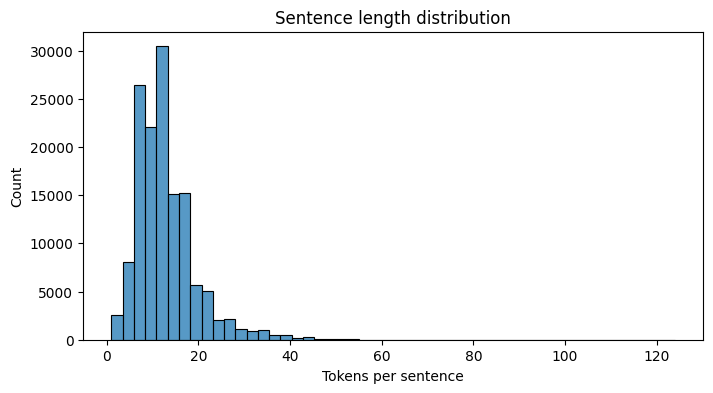

In [27]:
plt.figure(figsize=(8,4))
sns.histplot(sent_len, bins=50)
plt.title("Sentence length distribution")
plt.xlabel("Tokens per sentence")
plt.show()

# Preprocessing

## Downsampling

In [28]:
sent_counts = df.groupby("language")["sentence_id"].nunique()
print("Sentences by languages:\n", sent_counts)

# Min number of sentences
min_sents = sent_counts.min()
print("\nWill choose", min_sents, "sentences per language")

np.random.seed(42)

balanced_parts = []
for lang, group in df.groupby("language"):
    sent_ids = group["sentence_id"].unique()
    
    selected_ids = np.random.choice(sent_ids, size=min_sents, replace=False)
    
    balanced_part = group[group["sentence_id"].isin(selected_ids)]
    balanced_parts.append(balanced_part)

balanced_df = pd.concat(balanced_parts, ignore_index=True)

print("\nBalanced dataset:")
print(balanced_df.groupby("language")["sentence_id"].nunique())
print(balanced_df.groupby("language").size())

# Сохраняем
balanced_df.to_csv("balanced_data.csv", index=False)

print("\nSaved to balanced_data.csv")

Sentences by languages:
 language
en      14169
kaz    108161
ru      17345
Name: sentence_id, dtype: int64

Will choose 14169 sentences per language

Balanced dataset:
language
en     14169
kaz    14169
ru     14169
Name: sentence_id, dtype: int64
language
en     199826
kaz    165407
ru     264305
dtype: int64

Saved to balanced_data.csv


## After Downsampling analysis

In [29]:
df = pd.read_csv("balanced_data.csv")
df

,token,tag,language,sentence_id,source_split
0,EU,B-ORG,en,en_train_0,train
1,rejects,O,en,en_train_0,train
2,German,B-MISC,en,en_train_0,train
3,call,O,en,en_train_0,train
4,to,O,en,en_train_0,train
...,...,...,...,...,...
629533,поделилось,O,ru,ru_19999,train
629534,издание,O,ru,ru_19999,train
629535,Daily,B-ORG,ru,ru_19999,train
629536,Mail,I-ORG,ru,ru_19999,train


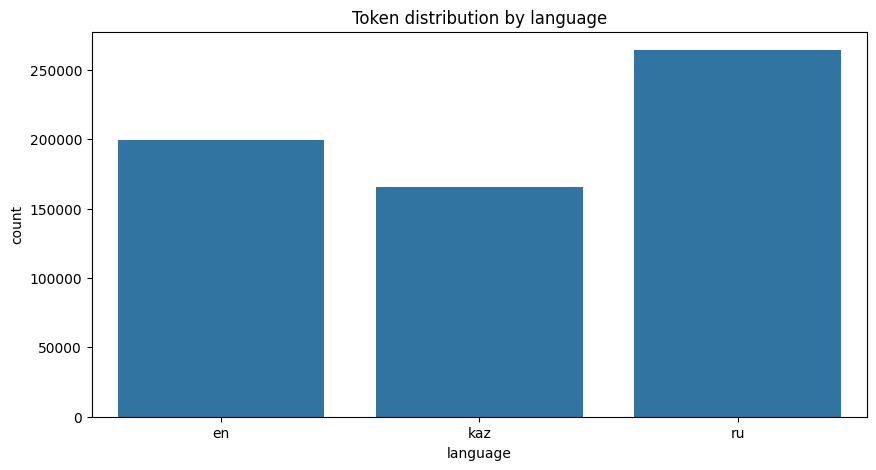

In [30]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="language")
plt.title("Token distribution by language")
plt.show()

In [31]:
tag_dist = (
    df.groupby(["language", "tag"])
      .size()
      .reset_index(name="count")
      .sort_values(["language", "count"], ascending=[True, False])
)

tag_dist.head(20)

,language,tag,count
8,en,O,169533
0,en,B-LOC,6419
3,en,B-PER,6052
2,en,B-ORG,5502
7,en,I-PER,4194
6,en,I-ORG,3054
1,en,B-MISC,3033
5,en,I-MISC,1041
4,en,I-LOC,998
57,kaz,O,130780


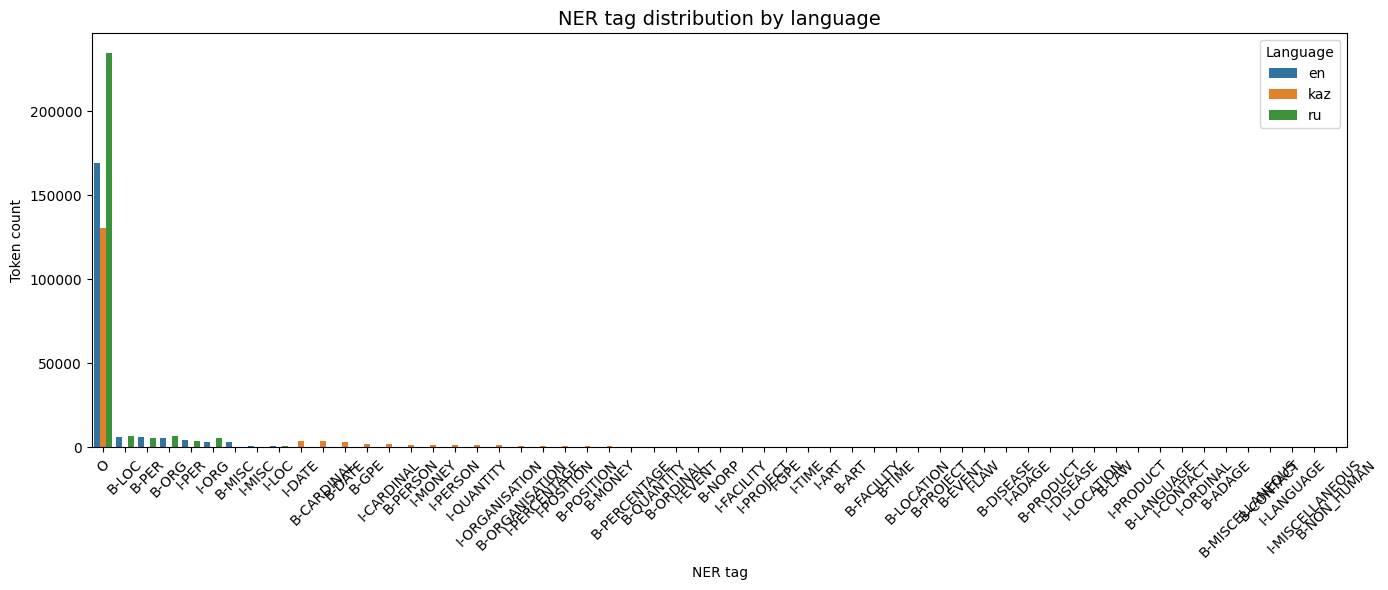

In [32]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=tag_dist,
    x="tag",
    y="count",
    hue="language"
)

plt.title("NER tag distribution by language", fontsize=14)
plt.xlabel("NER tag")
plt.ylabel("Token count")
plt.xticks(rotation=45)
plt.legend(title="Language")
plt.tight_layout()
plt.show()

In [33]:
tag_dist_no_o = tag_dist[tag_dist["tag"] != "O"]

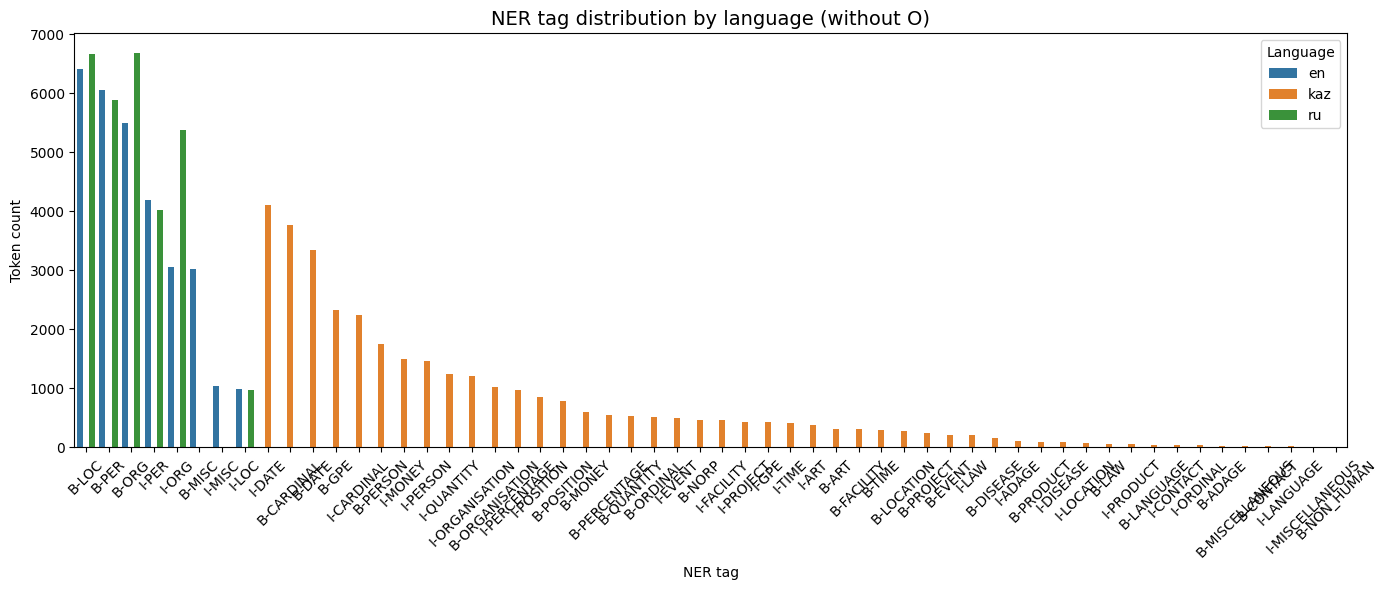

In [34]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=tag_dist_no_o,
    x="tag",
    y="count",
    hue="language"
)

plt.title("NER tag distribution by language (without O)", fontsize=14)
plt.xlabel("NER tag")
plt.ylabel("Token count")
plt.xticks(rotation=45)
plt.legend(title="Language")
plt.tight_layout()
plt.show()

## Normalization

In [35]:
df["tag"].value_counts()

tag
O                  534979
B-LOC               13094
B-ORG               12187
B-PER               11945
I-ORG                8439
I-PER                8220
I-DATE               4109
B-CARDINAL           3777
B-DATE               3345
B-MISC               3033
B-GPE                2322
I-CARDINAL           2251
I-LOC                1973
B-PERSON             1757
I-MONEY              1499
I-PERSON             1464
I-QUANTITY           1242
I-ORGANISATION       1218
I-MISC               1041
B-ORGANISATION       1022
I-PERCENTAGE          977
I-POSITION            853
B-POSITION            781
B-MONEY               596
B-PERCENTAGE          555
B-QUANTITY            538
B-ORDINAL             512
I-EVENT               505
B-NORP                471
I-FACILITY            458
I-PROJECT             429
I-GPE                 426
I-TIME                417
I-ART                 374
B-ART                 320
B-FACILITY            307
B-TIME                294
B-LOCATION            274
B-PROJEC

In [36]:
ENTITY_MAP = {
    # PERSON
    "PER": "PER",
    "PERSON": "PER",
    "POSITION": "PER",
    "NON_HUMAN": "PER",

    # LOCATION
    "LOC": "LOC",
    "GPE": "LOC",
    "LOCATION": "LOC",
    "FACILITY": "LOC",

    # ORGANIZATION
    "ORG": "ORG",
    "ORGANISATION": "ORG",
    "PROJECT": "ORG",

    # MISC (everything else)
    "DATE": "MISC",
    "TIME": "MISC",
    "CARDINAL": "MISC",
    "ORDINAL": "MISC",
    "MONEY": "MISC",
    "QUANTITY": "MISC",
    "PERCENTAGE": "MISC",
    "LAW": "MISC",
    "EVENT": "MISC",
    "ART": "MISC",
    "PRODUCT": "MISC",
    "LANGUAGE": "MISC",
    "NORP": "MISC",
    "DISEASE": "MISC",
    "CONTACT": "MISC",
    "ADAGE": "MISC",
    "MISCELLANEOUS": "MISC",
}

In [37]:
def normalize_tag(tag: str) -> str:
    if tag == "O":
        return "O"

    if "-" not in tag:
        return "O"

    prefix, ent = tag.split("-", 1)

    ent_norm = ENTITY_MAP.get(ent, "MISC")
    return f"{prefix}-{ent_norm}"

In [38]:
df["tag"] = df["tag"].apply(normalize_tag)

In [39]:
df["tag"].value_counts()

tag
O         534979
B-LOC      15997
B-PER      14485
B-MISC     14097
B-ORG      13452
I-MISC     12976
I-PER      10537
I-ORG      10086
I-LOC       2929
Name: count, dtype: int64

In [40]:
def find_bio_errors(df):
    errors = 0
    for _, group in df.groupby("sentence_id"):
        prev_tag = "O"
        for tag in group["tag"]:
            if tag.startswith("I-"):
                if prev_tag == "O" or prev_tag[2:] != tag[2:]:
                    errors += 1
            prev_tag = tag
    return errors

print("BIO errors:", find_bio_errors(df))

BIO errors: 4


In [41]:
def fix_bio_tags(df):
    fixed = df.copy()

    for sent_id, group in fixed.groupby("sentence_id"):
        prev_tag = "O"
        for idx in group.index:
            tag = fixed.at[idx, "tag"]

            if tag.startswith("I-"):
                ent = tag[2:]
                if prev_tag == "O" or prev_tag[2:] != ent:
                    fixed.at[idx, "tag"] = f"B-{ent}"

            prev_tag = fixed.at[idx, "tag"]

    return fixed

In [42]:
df = fix_bio_tags(df)

In [43]:
print("BIO errors:", find_bio_errors(df))

BIO errors: 0


## Analysis after Normalization

In [44]:
tag_dist = (
    df.groupby(["language", "tag"])
      .size()
      .reset_index(name="count")
)

In [45]:
tag_dist_no_o = tag_dist[tag_dist["tag"] != "O"]

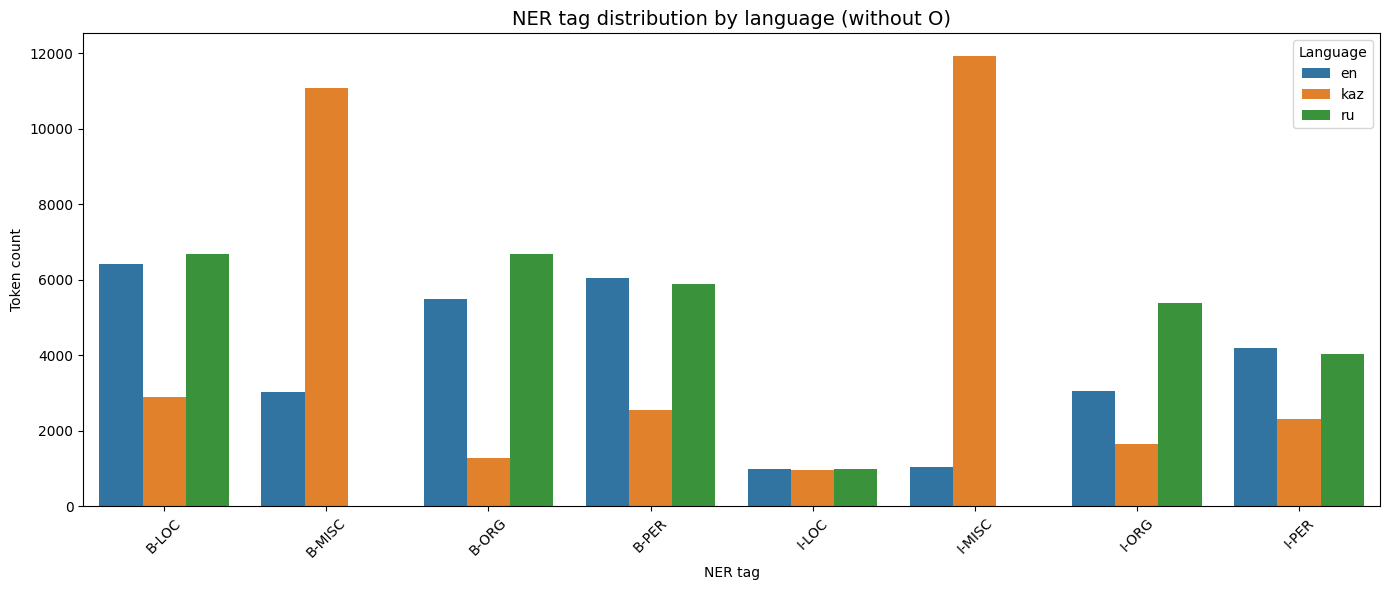

In [46]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=tag_dist_no_o,
    x="tag",
    y="count",
    hue="language"
)

plt.title("NER tag distribution by language (without O)", fontsize=14)
plt.xlabel("NER tag")
plt.ylabel("Token count")
plt.xticks(rotation=45)
plt.legend(title="Language")
plt.tight_layout()
plt.show()

In [48]:
# сколько уникальных sentence_id в каждом языке
print(df.groupby("language")["sentence_id"].nunique())

# есть ли sentence_id, которые встречаются в нескольких языках
tmp = df[["language","sentence_id"]].drop_duplicates()
collisions = (
    tmp.groupby("sentence_id")["language"].nunique().sort_values(ascending=False)
)
print("Sentence_ids appearing in >1 language:", (collisions > 1).sum())

language
en     14169
kaz    14169
ru     14169
Name: sentence_id, dtype: int64
Sentence_ids appearing in >1 language: 0


In [49]:
df

,token,tag,language,sentence_id,source_split
0,EU,B-ORG,en,en_train_0,train
1,rejects,O,en,en_train_0,train
2,German,B-MISC,en,en_train_0,train
3,call,O,en,en_train_0,train
4,to,O,en,en_train_0,train
...,...,...,...,...,...
629533,поделилось,O,ru,ru_19999,train
629534,издание,O,ru,ru_19999,train
629535,Daily,B-ORG,ru,ru_19999,train
629536,Mail,I-ORG,ru,ru_19999,train


In [52]:
df = df.drop(columns=["source_split"])

In [53]:
df

,token,tag,language,sentence_id
0,EU,B-ORG,en,en_train_0
1,rejects,O,en,en_train_0
2,German,B-MISC,en,en_train_0
3,call,O,en,en_train_0
4,to,O,en,en_train_0
...,...,...,...,...
629533,поделилось,O,ru,ru_19999
629534,издание,O,ru,ru_19999
629535,Daily,B-ORG,ru,ru_19999
629536,Mail,I-ORG,ru,ru_19999


In [54]:
from sklearn.model_selection import train_test_split
import pandas as pd

def final_split(df, test_size=0.1, val_size=0.1, random_state=42):
    parts = []

    for lang, lang_df in df.groupby("language"):
        sent_ids = lang_df["sentence_id"].unique()

        # 80% train, 20% temp
        train_ids, temp_ids = train_test_split(
            sent_ids,
            test_size=(test_size + val_size),
            random_state=random_state,
            shuffle=True
        )

        # 10% val, 10% test
        rel_test = test_size / (test_size + val_size)
        val_ids, test_ids = train_test_split(
            temp_ids,
            test_size=rel_test,
            random_state=random_state,
            shuffle=True
        )

        lang_df = lang_df.copy()
        lang_df["split"] = "train"
        lang_df.loc[lang_df["sentence_id"].isin(val_ids), "split"] = "validation"
        lang_df.loc[lang_df["sentence_id"].isin(test_ids), "split"] = "test"

        parts.append(lang_df)

    return pd.concat(parts, ignore_index=True)

In [55]:
df = final_split(df, test_size=0.1, val_size=0.1)

In [56]:
print(
    df.groupby(["split", "language"])["sentence_id"]
      .nunique()
      .unstack(fill_value=0)
)

language       en    kaz     ru
split                          
test         1417   1417   1417
train       11335  11335  11335
validation   1417   1417   1417


In [57]:
df.to_csv("ner_dataset.csv", index=False, encoding="utf-8")
print("Done. ner_dataset saved")

Done. ner_dataset saved
